In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('C:\\Users\\HP\\Documents\\finrisk\\data\\raw\\loan.csv')
df.shape
df.columns.to_list()

C:\Users\HP\AppData\Local\Temp\ipykernel_262456\2884162611.py:5: DtypeWarning: Columns (0: desc, 1: next_pymnt_d, 2: verification_status_joint, 3: sec_app_earliest_cr_line, 4: hardship_type, 5: hardship_reason, 6: hardship_status, 7: hardship_start_date, 8: hardship_end_date, 9: payment_plan_start_date, 10: hardship_loan_status, 11: debt_settlement_flag_date, 12: settlement_status, 13: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:\\Users\\HP\\Documents\\finrisk\\data\\raw\\loan.csv')


['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

In [4]:
# Convert 'issue_d' to datetime (LendingClub format is usually like 'Dec-2015')
df['issue_d_dt'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')

# Find the minimum and maximum dates
min_date = df['issue_d_dt'].min()
max_date = df['issue_d_dt'].max()

print(f"Earliest loan issue date: {min_date.strftime('%B %Y')}")
print(f"Latest loan issue date: {max_date.strftime('%B %Y')}")

Earliest loan issue date: June 2007
Latest loan issue date: December 2018


C:\Users\HP\AppData\Local\Temp\ipykernel_262456\681178607.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['issue_d_dt'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')


In [5]:
# Check for duplicate loan IDs
duplicate_loans = df['id'].duplicated().sum()

# Check for duplicate member IDs (customers)
duplicate_members = df['member_id'].duplicated().sum()

print(f"Number of duplicate loan IDs: {duplicate_loans}")
print(f"Number of duplicate member IDs: {duplicate_members}")

Number of duplicate loan IDs: 2260667
Number of duplicate member IDs: 2260667


In [6]:
# Check for missing values in critical fields
critical_columns = ['loan_amnt', 'annual_inc', 'loan_status', 'grade', 'term']
missing_critical = df[critical_columns].isnull().sum()
print("Missing values in critical fields:")
print(missing_critical)

Missing values in critical fields:
loan_amnt      0
annual_inc     4
loan_status    0
grade          0
term           0
dtype: int64


In [7]:
# Check percentage of missing values across all columns
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nTop columns with highest missing percentages:")
print(missing_percent[missing_percent > 0].sort_values(ascending=False).head(10))


Top columns with highest missing percentages:
id                                            100.000000
member_id                                     100.000000
url                                           100.000000
orig_projected_additional_accrued_interest     99.627278
hardship_loan_status                           99.530537
hardship_start_date                            99.530537
hardship_end_date                              99.530537
hardship_status                                99.530537
hardship_type                                  99.530537
hardship_amount                                99.530537
dtype: float64


Text(0, 0.5, 'Status')

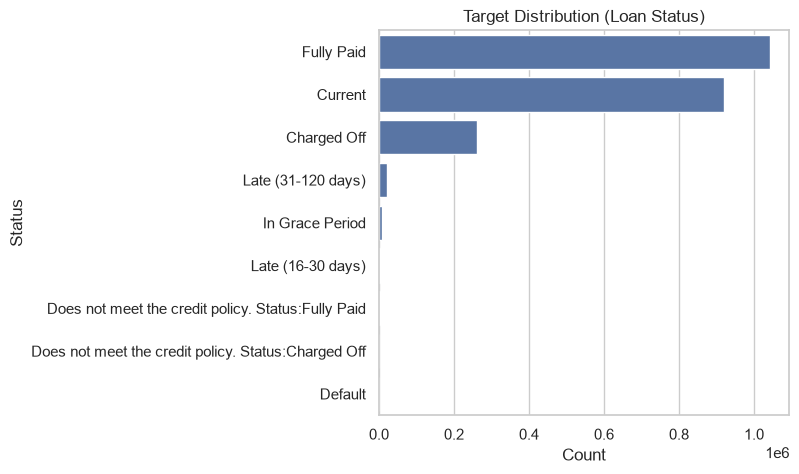

In [ ]:
# Set visual style and Target Distribution
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(y='loan_status', data=df, order=df['loan_status'].value_counts().index)
plt.title('Target Distribution (Loan Status)')
plt.xlabel('Count')
plt.ylabel('Status')

Text(0, 0.5, 'Frequency')

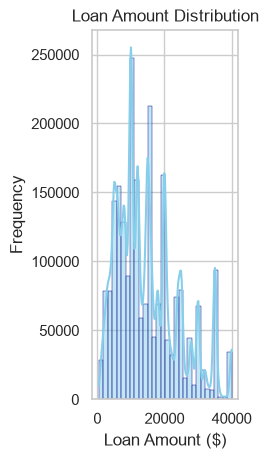

In [16]:
#  Loan Amount Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['loan_amnt'], bins=30, kde=True, color='skyblue',edgecolor='darkblue')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Frequency')


C:\Users\HP\AppData\Local\Temp\ipykernel_262456\1636891104.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='grade', data=df, order=sorted(df['grade'].dropna().unique()), palette='viridis')


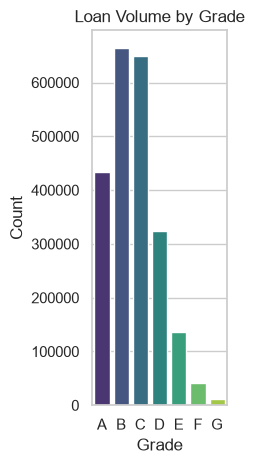

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

In [11]:

# Loan Grade Distribution
plt.subplot(1, 3, 3)
sns.countplot(x='grade', data=df, order=sorted(df['grade'].dropna().unique()), palette='viridis')
plt.title('Loan Volume by Grade')
plt.xlabel('Grade')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

df['loan_status'].value_counts()